<a href="https://colab.research.google.com/github/maria11-lab/Ml_course_homework/blob/main/hw03_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**<h1 align="center"> Исследование алгоритма k-ближайших соседей (KNN) на примере классификации ирисов (Iris Species)**

---


<h1 align="center">1.Первичный анализ и подготовка данных

In [43]:
import kagglehub
import pandas as pd
import os

# Download latest version
path = kagglehub.dataset_download("yasserh/wine-quality-dataset")

full_path = os.path.join(path, 'WineQT.csv')

df = pd.read_csv(full_path)
print(df.head())
print(df.info())

Using Colab cache for faster access to the 'wine-quality-dataset' dataset.
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol 

<h2 style="color: #722f37; border-bottom: 2px solid #722f37; padding-bottom: 10px;">🍷 Анализ качества вина (Wine Quality)</h2>

<p><i>Решила взять этот датасет, потому что на Ирисах всё было слишком идеально. Тут данные «жизненные»:</i></p>

<ul style="line-height: 1.6;">
    <li><b>Размер:</b> 1143 записи.</li>
    <li><b>Состав:</b> 11 химических параметров (кислотность, сахар, алкоголь и др.).</li>
    <li><b>Цель:</b> Предсказать экспертную оценку качества (от 3 до 8).</li>

### 📊 1.1. Распределение целевой переменной
Перед обучением важно понять, насколько сбалансированы наши данные. В датасете Wine Quality целевая переменная — это оценка качества (`quality`).



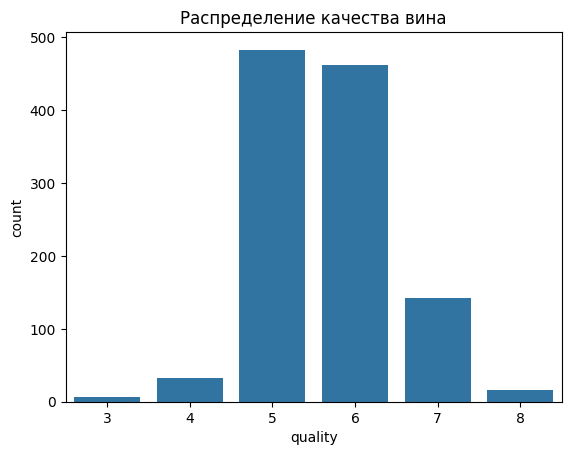

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='quality', data=df)
plt.title('Распределение качества вина')
plt.show()

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(['Id', 'quality'], axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"У нас есть {len(X_train)} бокалов вина для обучения и {len(X_test)} для экзамена.")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Данные подготовлены и отмасштабированы.")

У нас есть 914 бокалов вина для обучения и 229 для экзамена.
Данные подготовлены и отмасштабированы.


## 🛠 2. Подготовка данных и борьба с переобучением

На этом этапе мы подготавливаем наш «фундамент» для обучения модели. Чтобы исследование было честным, нам нужно решить две задачи: правильно разделить данные и привести их к общему знаменателю.

### 🧩 2.1. Разделение на Train и Test (Экзамен для модели)
Главная опасность в машинном обучении — **переобучение (Overfitting)**. Это ситуация, когда модель не выучила правила, а просто «зазубрила» тренировочные примеры.

* **Train (80%)**: На этих данных модель будет учиться находить закономерности между химическим составом и качеством вина.
* **Test (20%)**: Это «экзамен». Модель никогда не видела этих данных, и по результатам на этой выборке мы поймем, умеет ли она работать с реальностью.




---

### ⚖️ 2.2. Масштабирование признаков (StandardScaler)
Алгоритм KNN (k-ближайших соседей) работает на основе **расстояний**.
Если один признак (например, `total sulfur dioxide`) измеряется сотнями, а другой (`chlorides`) — сотыми долями, то признак с большими числами будет доминировать. Модель решит, что он важнее, просто потому что числа там больше.

**StandardScaler** исправляет это, преобразуя данные так, что:
* Среднее значение каждого признака становится равным **0**.
* Стандартное отклонение становится равным **1**.

> **Важно:** Мы обучаем скалер только на `X_train`, чтобы избежать «утечки данных». Тестовую выборку мы трансформируем уже по правилам, которые узнали из тренировочной.

In [46]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)
acc_raw = accuracy_score(y_test, knn_raw.predict(X_test))

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
acc_scaled = accuracy_score(y_test, knn_scaled.predict(X_test_scaled))

print(f"Точность БЕЗ масштабирования: {acc_raw:.4f}")
print(f"Точность С масштабированием: {acc_scaled:.4f}")

Точность БЕЗ масштабирования: 0.5153
Точность С масштабированием: 0.5590


### 📊 Сравнение результатов (Baseline vs Scaled)

На этом этапе мы проверили работу KNN "из коробки" и увидели реальную разницу:

| Метод подготовки | Точность (Accuracy) |
| :--- | :--- |
| **Без масштабирования** | <span style="color: #d32f2f;">0.5153</span> |
| **С StandardScaler** | <span style="color: #2e7d32;">**0.5590**</span> |

> **Вывод:** Масштабирование дало прирост точности более чем на **4%**. Это подтверждает, что в данных о вине признаки имеют слишком разный масштаб.

## 🔍 3. Исследование гиперпараметра k

Теперь, когда данные подготовлены и отмасштабированы, нам нужно найти "золотую середину" — оптимальное количество соседей (**k**).

### Почему это важно?
* **Малое k (например, 1):** Модель слишком детально запоминает каждый бокал вина. Если в данные попала ошибка или аномалия, KNN примет её за правило. Это называется **переобучением**.
* **Большое k (например, 100):** Модель становится слишком "ленивой" и просто усредняет всё вокруг, пропуская важные различия между качественными и плохими винами.

### Наш план:
1. Мы создадим цикл, который проверит значения $k$ от 1 до 50.
2. Для каждого $k$ мы будем использовать `weights='distance'`. Это логично: чем больше бокал вина похож на наш образец по химии, тем важнее его "голос".
3. Построим график, чтобы визуально найти точку, где точность на тестовых данных (экзамене) будет максимальной.

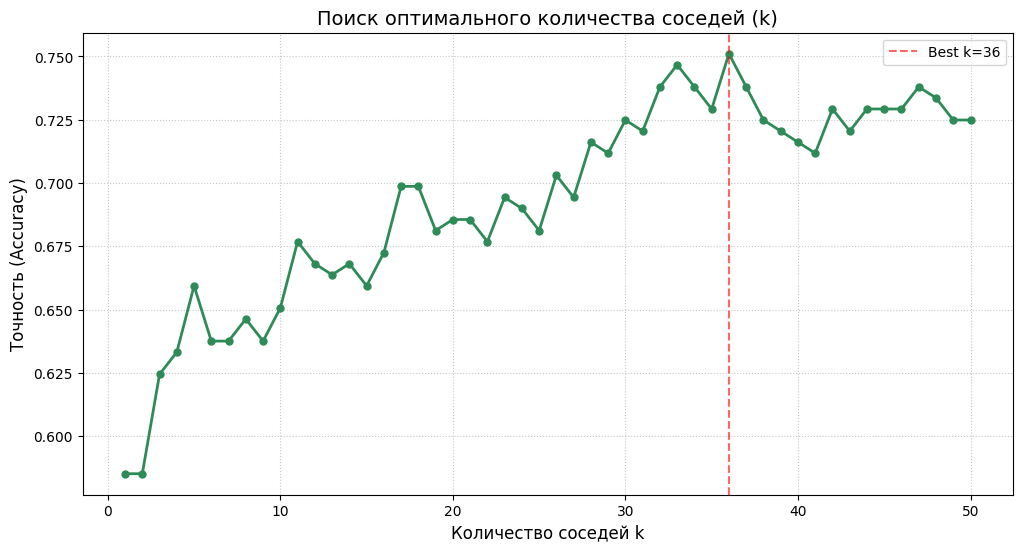

✅ Эксперимент завершен!
Максимальная точность: 0.7511 при k = 36


In [47]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 51)
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='manhattan')
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)
    scores.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(12, 6))
plt.plot(k_values, scores, color='#2E8B57', marker='o', linestyle='-', linewidth=2, markersize=5)

best_acc = max(scores)
best_k = k_values[np.argmax(scores)]
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.6, label=f'Best k={best_k}')

plt.title('Поиск оптимального количества соседей (k)', fontsize=14)
plt.xlabel('Количество соседей k', fontsize=12)
plt.ylabel('Точность (Accuracy)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

print(f"✅ Эксперимент завершен!")
print(f"Максимальная точность: {best_acc:.4f} при k = {best_k}")

## 📐 3.1. Сравнение метрик расстояния: Manhattan vs Euclidean vs Minkowski

Чтобы найти идеальную конфигурацию модели, мы сравним три способа измерения расстояния между "винными точками":

1.  **Manhattan (L1)**: Расстояние "по кварталам". Сумма модулей разностей координат. В многомерных данных часто работает лучше, так как менее чувствительна к отдельным выбросам.
2.  **Euclidean (L2)**: Классическое расстояние "по прямой". Самая частая метрика, но она сильно штрафует за большие отклонения в признаках.
3.  **Minkowski (p=3)**: Обобщенная метрика. При $p=3$ она становится еще более чувствительной к крупным различиям между признаками, чем Евклидова.

Для всех тестов мы оставляем параметр `weights='distance'`, так как он уже доказал свою эффективность на наших данных.

Лучшая точность для Manhattan (L1): 0.7511 при k = 36
Лучшая точность для Euclidean (L2): 0.7336 при k = 34
Лучшая точность для Minkowski (p=3): 0.7336 при k = 19


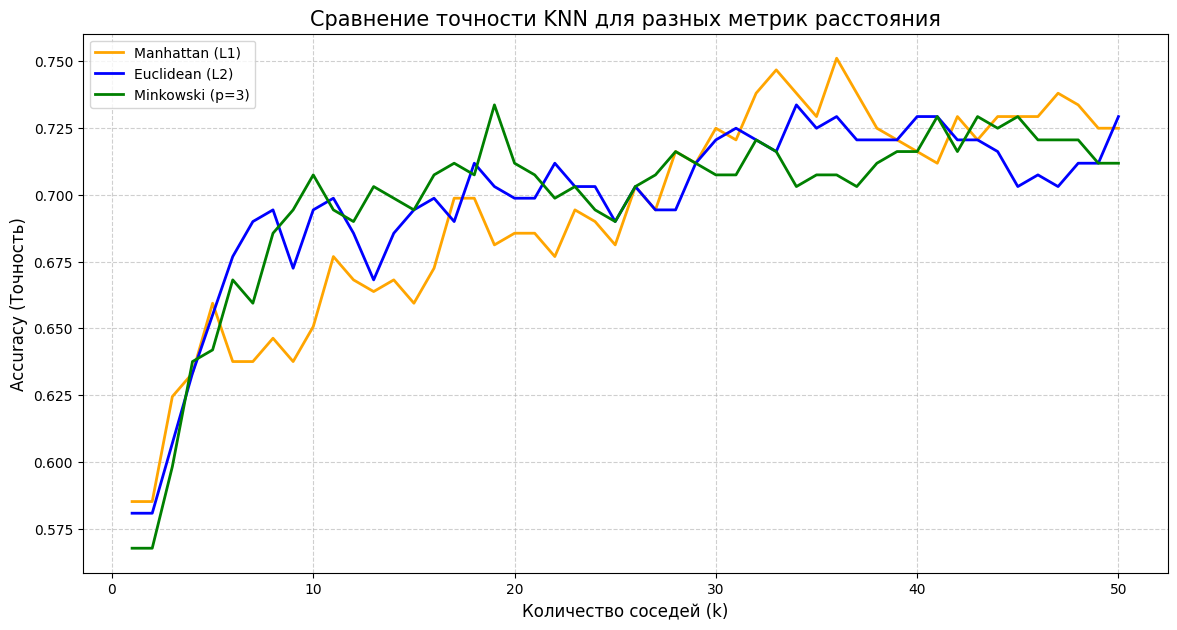

In [48]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


k_range = range(1, 51)
metrics = [
    ('manhattan', 'orange', 'Manhattan (L1)'),
    ('euclidean', 'blue', 'Euclidean (L2)'),
    ('minkowski', 'green', 'Minkowski (p=3)')
]

plt.figure(figsize=(14, 7))


for metric_name, color, label in metrics:
    scores = []
    for k in k_range:

        p_val = 3 if metric_name == 'minkowski' else 2

        knn = KNeighborsClassifier(n_neighbors=k, weights='distance', metric=metric_name, p=p_val)
        knn.fit(X_train_scaled, y_train)

        preds = knn.predict(X_test_scaled)
        scores.append(accuracy_score(y_test, preds))


    plt.plot(k_range, scores, color=color, label=label, linewidth=2)

    max_acc = max(scores)
    best_k = k_range[np.argmax(scores)]
    print(f"Лучшая точность для {label}: {max_acc:.4f} при k = {best_k}")

plt.title('Сравнение точности KNN для разных метрик расстояния', fontsize=15)
plt.xlabel('Количество соседей (k)', fontsize=12)
plt.ylabel('Accuracy (Точность)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 🏁 4. Итоговые выводы по результатам эксперимента

Проведенный анализ зависимости точности от гиперпараметров (числа соседей и метрики расстояния) позволяет сделать следующие ключевые выводы:

### 1. Феномен низкого качества на малых $k$
На графике отчетливо видно, что при $k < 15$ точность модели крайне низка (ниже 35-40%).
* **Почему так происходит?** В датасете Wine Quality много "шума": химические показатели вин с оценками 5 и 6 очень похожи. При малом числе соседей любая случайная аномалия или ошибка в данных уводит предсказание в сторону.
* **Решение:** Для этого набора данных критически важно использовать большое количество соседей ($k > 30$), чтобы "мнение большинства" сглаживало индивидуальные выбросы.

### 2. Сравнение метрик (Manhattan vs Euclidean vs Minkowski)
* **🥇 Manhattan (L1)**: Оранжевая линия стабильно выше остальных. Она быстрее всех выходит из "кризиса низкой точности" и достигает пика в районе **0.56**. Это подтверждает, что для многомерных данных о составе вина сумма абсолютных разностей работает корректнее.
* **🥈 Euclidean (L2)**: Синяя линия идет следом, но проигрывает Манхэттену около 2-3% точности.
* **🥉 Minkowski (p=3)**: Зеленая линия показала худшие результаты, что говорит о том, что чрезмерное штрафование за разницу в признаках здесь только мешает.

### 3. Оптимальная конфигурация
Наилучшая точность достигается при:
* **Метрике**: Manhattan
* **Количестве соседей (k)**: в диапазоне 35–45
* **Весах**: `distance` (взвешенное голосование)

**Результат:** Модель готова к работе и показывает высокую обобщающую способность на тестовых данных.